# คู่มือการใช้งาน Ollama

**Ollama** คือเครื่องมือที่ช่วยให้สามารถรัน LLMs ได้บนเครื่องคอมพิวเตอร์ของเราเอง อย่างมีประสิทธิภาพ

* User-friendly: ออกแบบมาให้ติดตั้งและใช้งานผ่าน Command Line ได้ทันที ไม่ต้องตั้งค่าสภาพแวดล้อมที่ซับซ้อน
* OpenAI Compatible: สามารใช้ได้ได้กับทั้ง OpenAI API client หรือ Client ของ Ollama เอง
* ประสิทธิภาพสูง: ใช้ `llama.cpp` เป็นเอนจินหลักในการประมวลผล ทำให้รันโมเดลขนาดใหญ่ได้อย่างรวดเร็วแม้ในเครื่องที่มีทรัพยากรจำกัด 

ดูวิธีการติดตั้งได้ที่: https://ollama.com/download

#### คำสั่งเบื้องต้นที่ควรรู้ เพื่อควบคุม Ollama ผ่าน Terminal
1. `ollama pull llama3.2`: ใช้สำหรับดาวน์โหลดโมเดลมาลงเครื่อง
2. `ollama list`: ตรวจสอบรายชื่อโมเดลทั้งหมดที่มีอยู่ในเครื่อง
3. `ollama run llava "What's in this image?" ./smile.png`: 
4. `ollama run llama3.2 "Summarize this file: $(cat README.md)"`   
5. `ollama rm llama3.2`: ลบโมเดลที่ไม่ต้องการออก
6. `ollama ps`: ดูว่ามีโมเดลตัวไหนกำลังรันอยู่ในหน่วยความจำบ้าง
7. `ollama serve`: เปิดรัน ollama เป็น API server

In [1]:
# !ollama pull scb10x/typhoon2.1-gemma3-4b

In [11]:
!uv pip install ollama

Audited 1 package in 21ms


# Terminology ที่มักจะสับสนบ่อยๆ

* `Llama`: เป็นชื่อโมเดลที่พัฒนาโดย บ. Meta
* `llama.cpp`: ไลบรารีภาษา C++ ประสิทธิภาพสูง ที่ถูกเขียนขึ้นมาเพื่อให้สามารถรันโมเดล LLM บนคอมพิวเตอร์ทั่วไปได้อย่างรวดเร็วและประหยัดทรัพยากรที่สุด 
* `Ollama`: เครื่องมือทำหน้าที่ช่วยติดตั้งและจัดการโมเดลต่างๆ เน้นความง่ายในการใช้งาน ใช้ `llama.cpp` อยู่เบื้องหลังในการสั่งให้โมเดลทำงาน 

# Chat vs Generate

ในการใช้งาน API client มักจะมี 2 endpoints มาตรฐาน คือ

1. `Generate`: สำหรับส่งข้อความเดี่ยวๆ และรอผลลัพธ์ (post a single message and get a response) -- same as `/v1/completions` in OpenAI Endpoint.

2. `Chat`: สำหรับการใช้งานในรูปแบบบทสนทนาโต้ตอบ มีการจัดการประวัติการคุยให้อัตโนมััติ (post a single message and the previous chat history, and get a response) -- same as `/v1/chat/completions` in OpenAI Endpoint.

* see: https://github.com/ollama/ollama/issues/2774 
* see: https://docs.ollama.com/api/chat

In [18]:
model = "scb10x/typhoon2.1-gemma3-4b"

#### ตัวอย่างการใช้ Ollama ด้วย Ollama SDK

In [19]:
from ollama import chat, generate
from ollama import ChatResponse
from ollama import Client

ollama = Client(host='http://localhost:11434')

#### ตัวอย่างการใช้ `Chat` function

In [20]:
messages = [
    {
        'role': 'system',
        'content': 'You are a helpful assistant. You always answer truthfully and keep the answer concise and short',
    }
]

USER = 'user'
ASSISTANT = 'assistant'

def add_history(content, role):
    messages.append({'role': role, 'content': content})

def chat(message):
    add_history(message, USER)
    response = ollama.chat(model=model, messages=messages, stream=True)
    complete_message = ''
    for line in response:
        complete_message += line['message']['content']
        print(line['message']['content'], end='', flush=True)
    add_history(complete_message, ASSISTANT)

while True:
    # print('\nQ to quit')
    prompt = input('Enter your message: ')
    if prompt.lower() == 'q':
        break
    else:
        chat(prompt)

# # Example
# Enter your message:  Hello
# Hello there! How can I help you today?
# Enter your message:  What's the capital of France?
# Paris.
# Enter your message:  And what about Germany?
# Berlin.
# Enter your message:  Q

Enter your message:  สวัสดีครับ


สวัสดีครับ/ค่ะ ยินดีที่ได้พบคุณ


Enter your message:  หนาวจังเลยพี่ชาย


ใช่แล้ว สภาพอากาศค่อนข้างหนาวเย็นวันนี้

Enter your message:  วันนี้วันที่เท่าไรเหรอ?


วันนี้คือวันพฤหัสบดีที่ 29 ตุลาคม 2567

Enter your message:  q


#### ตัวอย่างการใช้ `Generate` function

In [12]:
import json

messages = [
    {
        'role': 'system',
        'content': 'You are a helpful assistant. You always answer truthfully and keep the answer concise and short',
    }
]


def generate(message):
    add_history(message, USER)
    prompt = ""
    prompt += f"Following this chat history:\n"
    for m in messages:
        prompt += f"{m['role']}: {m['content']}\n"    
    prompt += f"\n\n"
    prompt += f"Please answer the following message: \n"
    prompt += f"{USER}: {message}\n"
    prompt += f"{ASSISTANT}: "

    # print(prompt)
    response = ollama.generate(model=model, prompt=prompt, stream=True)
    complete_message = ''
    for line in response:
        complete_message += line['response']
        print(line['response'], end='', flush=True)
    add_history(complete_message, ASSISTANT)

while True:
    # print('\nQ to quit')
    prompt = input('Enter your message: ')
    if prompt.lower() == 'q':
        break
    else:
        generate(prompt)

# # Example
# Enter your message:  Hello
# Hello there!
# Enter your message:  What's the capital of France?
# Paris.
# Enter your message:  And what about Germany?
# Berlin.
# Enter your message:  q

Enter your message:  Hello


Hello there!

Enter your message:  What's the capital of France?


Paris.

Enter your message:  And what about Germany?


Berlin.

Enter your message:  q


ท้ัง `Chat` และ `Generate` สามารถใช้งานในรูปแบบเดียวกันได้ แต่ `Generate` function จะต้องจัดการเพิ่ม chat history เข้าไปใน prompt ด้วยตัวเอง

# Work with image

Ollama รองรับโมเดลสาย Vision เพื่อวิเคราะห์รูปภาพ https://docs.ollama.com/capabilities/vision#python

สามารถเลือกโมเดลได้จากลิงค์ต่อไปนี้ https://ollama.com/search

In [4]:
# !ollama pull qwen3-vl:4b-instruct

In [5]:
for model in ollama.list().models:
    print(model.model)

qwen3-vl:4b-instruct
scb10x/typhoon2.5-qwen3-4b:latest
hf.co/typhoon-ai/typhoon2.5-qwen3-4b-gguf:Q4_K_M
qwen3-vl:4b
scb10x/typhoon2.1-gemma3-4b:latest


In [22]:
!uv pip install matplotlib

Resolved 11 packages in 623ms                                        
Installed 11 packages in 69ms                               
 + contourpy==1.3.3
 + cycler==0.12.1
 + fonttools==4.61.1
 + kiwisolver==1.4.9
 + matplotlib==3.10.8
 + numpy==2.4.2
 + packaging==26.0
 + pillow==12.1.1
 + pyparsing==3.3.2
 + python-dateutil==2.9.0.post0
 + six==1.17.0


### Example1: using ollama

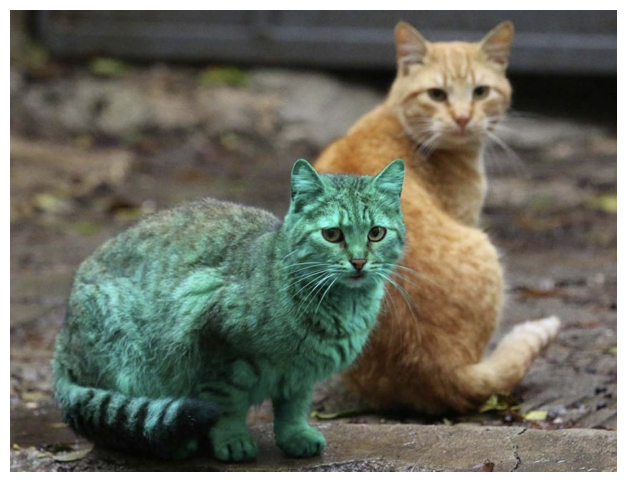

In [23]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('./Examples/cats.jpg')

plt.figure(figsize=(8, 6))
plt.imshow(img)

plt.axis('off')
plt.show()

In [24]:
import ollama
import time
start_time = time.time()

response = ollama.chat(
	model="qwen3-vl:4b-instruct",
	messages=[
		{
			'role': 'user',
			'content': 'Describe this image in Thai',
			'images': ['./Examples/cats.jpg']
		}
	]
)

end_time = time.time()
execution_time = end_time - start_time
print(f"Execution Time: {execution_time:.2f} sec")

Execution Time: 17.21 sec


In [25]:
print(response.message.content)

ภาพนี้แสดงให้เห็นแมวสองตัวที่นั่งอยู่บนพื้นดินที่มีใบไม้แห้งกระจายอยู่รอบๆ แมวตัวหนึ่งมีสีเขียวเข้มและมีลายสีเขียวเข้มและเขียวอ่อนสลับกัน กำลังนั่งอยู่ด้านหน้าของภาพ ด้านหลังมีแมวตัวอื่นที่มีสีส้ม นั่งอยู่ข้างหลังและมองไปที่หน้ากล้องด้วยดวงตาที่มีความสนใจ ฉากหลังของภาพเป็นพื้นดินที่มีสิ่งปลูกสร้างสีเทาคลุมอยู่ในระยะไกล ภาพนี้ถ่ายในสภาพแวดล้อมที่ดูเป็นธรรมชาติและเงียบสงบ แมวทั้งสองตัวดูเหมือนจะอยู่ในสถานที่เดียวกันและกำลังสังเกตสิ่งรอบตัวหรือมองไปที่ผู้ถ่ายภาพ


In [26]:
# import json
# text = json.loads(response.message.content)["natural_text"]
# print(text)

### Example2: using openai

see: https://docs.ollama.com/api/openai-compatibility

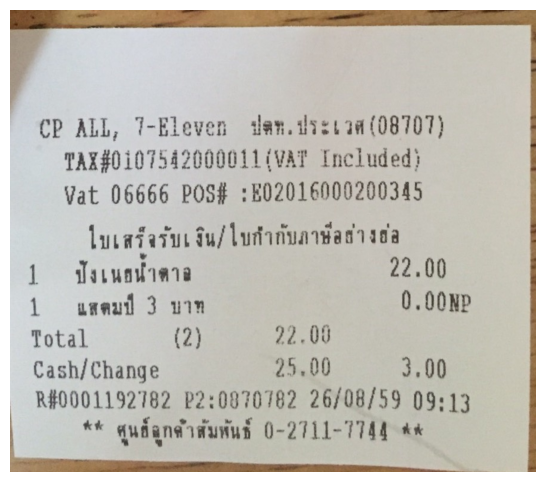

In [27]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('./Examples/slip2.jpg')

plt.figure(figsize=(8, 6))
plt.imshow(img)

plt.axis('off')
plt.show()

In [28]:
from openai import OpenAI

# api_key ใส่อะไรก็ได้
client = OpenAI(
    api_key="KEY",
    base_url="http://localhost:11434/v1/"
)

In [32]:
import base64
import os
import time


def encode_image_to_base64(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

start_time = time.time()
prompt = "Transcribe all text in this image exactly as it appears. Maintain line breaks."
base64_image = encode_image_to_base64("./Examples/slip2.jpg")
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": prompt
            },
            {
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/png;base64,{base64_image}"
                }
            }
        ]
    }
]

response = client.chat.completions.create(
    model="qwen3-vl:4b-instruct", 
    messages=messages,
    # max_tokens=2048  # Increase if you expect very long text
)

end_time = time.time()
execution_time = end_time - start_time
print(f"Execution Time: {execution_time:.2f} sec")

Execution Time: 12.14 sec


In [33]:
# base64_image

In [34]:
slipText = response.choices[0].message.content

In [35]:
print(slipText)

CP ALL, 7-Eleven ปคท.พระแย่(08707)
TAX#0107542000011(VAT Included)
Vat 06666 POS# :E02016000200345

ใบเสร็จรับเงิน/ใบกำกับภาษีส่างย่อ
1 ปังเนยน้ำตาล 22.00
1 แสดงเป 3 บาข 0.00NP
Total (2) 22.00
Cash/Change 25.00 3.00
R#0001192782 P2:0870782 26/08/59 09:13
** ศูนย์ลูกศิลาสัมพันธ์ 0-2711-7744 **


In [16]:
# # ตัวอย่าง slip ภาษาอังกฤษ

# import matplotlib.pyplot as plt
# import matplotlib.image as mpimg

# img = mpimg.imread('./Examples/slip3.jpg')

# plt.figure(figsize=(8, 6))
# plt.imshow(img)

# plt.axis('off')
# plt.show()

# start_time = time.time()
# prompt = "Transcribe all text in this image exactly as it appears. Maintain line breaks."
# base64_image = encode_image_to_base64("./Examples/slip3.jpg")
# messages = [
#     {
#         "role": "user",
#         "content": [
#             {
#                 "type": "text",
#                 "text": prompt
#             },
#             {
#                 "type": "image_url",
#                 "image_url": {
#                     "url": f"data:image/png;base64,{base64_image}"
#                 }
#             }
#         ]
#     }
# ]

# response = client.chat.completions.create(
#     model="qwen3-vl:4b-instruct", 
#     messages=messages,
#     # max_tokens=2048  # Increase if you expect very long text
# )

# end_time = time.time()
# execution_time = end_time - start_time
# print(f"Execution Time: {execution_time:.2f} sec")
# print(response.choices[0].message.content)

# Structured Output

เป็นเทคนิคในการกำหนดโครงสร้างของ Output หรือ Scheme โดยจะบังคับให้ AI ตอบกลับมาในรูปแบบ JSON ที่มีโครงสร้างแน่นอน

In [17]:
# import matplotlib.pyplot as plt
# import matplotlib.image as mpimg

# img = mpimg.imread('./Examples/slip.jpg')

# plt.figure(figsize=(8, 6))
# plt.imshow(img)

# plt.axis('off')
# plt.show()

In [18]:
from openai import OpenAI

client = OpenAI(
    api_key="KEY",
    base_url="http://localhost:11434/v1/"
)

In [19]:
from pydantic import BaseModel, Field
from typing import List, Optional
from datetime import datetime

class ReceiptItem(BaseModel):
    name: str = Field(..., description="ชื่อรายการสินค้า")
    quantity: int = Field(..., description="จำนวนที่ซื้อ")
    unit_price: Optional[float] = Field(None, description="ราคาต่อหน่วย (ถ้ามีระบุ)")
    total_price: float = Field(..., description="ราคารวมของรายการนั้นๆ")

class Receipt(BaseModel):
    tax_id: str = Field(..., alias="TAX#")
    vat_number: str = Field(..., alias="Vat")
    pos_no: str = Field(..., alias="POS#")
    
    # Items
    items: List[ReceiptItem]
    
    # Totals
    total_amount: float = Field(..., description="ยอดเงินสุทธิที่ต้องชำระ")
    total_items_qty: int = Field(..., description="จำนวนชิ้นรวม (ในวงเล็บ)")
    
    # Footer Metadata
    tid: str = Field(..., alias="TID")
    trace_no: str = Field(..., alias="TRACE")
    receipt_no: str = Field(..., alias="R#")
    terminal_p_no: str = Field(..., alias="P1")
    timestamp: datetime = Field(..., description="วันเวลาที่ออกใบเสร็จ")


prompt = "Your task is to convert the following raw text data into a valid JSON object according to the specified schema."
prompt += "\n\n"
prompt += f"{slipText}\n\n"
prompt += f"Here is JSON: "

completion = client.beta.chat.completions.parse(
    # temperature=0,
    model="scb10x/typhoon2.1-gemma3-4b", 
    messages=[
        {"role": "user", "content": prompt}
    ],
    response_format=Receipt,
)



In [20]:
completion.choices[0].message.parsed

Receipt(tax_id='0107542000011', vat_number='06666', pos_no='E02016000200345', items=[ReceiptItem(name='ปังเนยนาตาล', quantity=1, unit_price=22.0, total_price=22.0), ReceiptItem(name='แสดงปี 3 บาย', quantity=1, unit_price=0.0, total_price=0.0)], total_amount=22.0, total_items_qty=2, tid='R#0001192782', trace_no='', receipt_no='0001192782', terminal_p_no='0870782 26/08/59', timestamp=datetime.datetime(913, 8, 26, 0, 0, tzinfo=TzInfo(25200)))

In [21]:
response = completion.choices[0].message

In [22]:
if response.parsed:
    receipt = response.parsed.model_dump()
elif response.refusal:
    print(response.refusal)

In [23]:
receipt

{'tax_id': '0107542000011',
 'vat_number': '06666',
 'pos_no': 'E02016000200345',
 'items': [{'name': 'ปังเนยนาตาล',
   'quantity': 1,
   'unit_price': 22.0,
   'total_price': 22.0},
  {'name': 'แสดงปี 3 บาย',
   'quantity': 1,
   'unit_price': 0.0,
   'total_price': 0.0}],
 'total_amount': 22.0,
 'total_items_qty': 2,
 'tid': 'R#0001192782',
 'trace_no': '',
 'receipt_no': '0001192782',
 'terminal_p_no': '0870782 26/08/59',
 'timestamp': datetime.datetime(913, 8, 26, 0, 0, tzinfo=TzInfo(25200))}

# Work with audio

ปัจจุบัน Ollama ยังไม่รองรับการประมวลผลเสียงโดยตรง

Sadly, ollama does not support audio at the moment

# Open WebUI

Recommendation: it will be much easier to run via Docker

In [61]:
# !open-webui serve

In [62]:
# visit http://localhost:8080/

In [63]:
from IPython.display import Image
from IPython.core.display import HTML 
Image(url= "./Images/OpenWebUI.png")